<div style="color:#FF9900;background-color:#C1C99D;text-align:center;padding-top: 90px; padding-right: 30px; padding-bottom: 90px; padding-left: 80px;">
    <h1>
        M304- Naive Bayes on- Donar Choose Dataset, Running Assignemnts-4
    </h1>
</div>


<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        1. Business Case, ML Problem, Data, Metrics and Constraints
    </h1>
</div>

<h2 style="color:#C00000;"> 1.1 Business Problem </h2>

<h2 style="color:#C00000;"> 1.1.1 About DonorChoose </h2>

<p style="color:gray";>
DonorsChoose is a United States-based non-profit organization that allows individuals to donate directly to public school classroom projects. The organization has been given Charity Navigator’s highest rating every year since 2005. In January 2018, they announced that 1 million projects had been funded.
</p>
<hr>

<p style="color:gray";>
At <a href="www.donorschoose.org"> Donorchoose.org </a>, educators propose an idea for a student project by writing a brief essay and completing some simple forms. Volunteers screen proposals to ensure that projects will directly serve students and to confirm the cost and availability of the resources that the educator requests.Then, individuals from across the nation can review and choose to fund the proposal(s) they find most compelling.
</p>

<hr>

<h2 style="color:#C00000;"> 1.2 Data Overview</h2>

<b>About the Dataset :</b> The dataset consist of two parts :

- train.csv : Contains the Training set
- resources.csv : Contains the resources requested by each proposal
Kaggle Link : https://www.kaggle.com/c/donorschoose-application-screening

<h2 style="color:#C00000;"> 1.3 Mapping ML Problem</h2>

1. It's a classification problem: Given a proposal classify weather project will be recive good funding or not
2. Metrics: Accuracy, and Some sense Interpretability
3. No latancy constraints as such

<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        2. Preprocessing I: Cleaning and Organizing
    </h1>
</div>

<h2 style="color:#C00000;"> 2.1 Data Preprocessing</h2>
<hr>

<h4 syle="color:gray;">
<a href="https://medium.com/@rajneeshjha9s/naive-bayes-model-on-donorschoose-dataset-547302bc1fd3"> All the Data Preprocessing Done by Mr. Rajneesh Jha, We will use it directly here </a> </h4>

In [1]:
#Try yourself for practice, the preprocessing is very similar to Amazon fine food review

<h2 style="color:#C00000;"> 2.2 Text Preprocessing: Cleaning </h2>
<h3 style="color:#C00000;"> 2.2.1 Preprocessing Essay</h3>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Try all these on google colab then download the notebook for revision-







#we directy start from here !

<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        3. Featurizing, Organizing and Splitting
    </h1>
</div>

Cleaning and Featurizing Should be diffent because we try multiple feturization, techniques and strategies for Improvements

<h3 style="color:#C00000;"> 3 Loading Preprocessed Data </h3>

In [5]:
#1. Loading clean data
data_path = '/content/drive/MyDrive/Data Science/Notebooks AAI/Module 3/Donorchoose.csv'

df = pd.read_csv(data_path)
print("Data Shape: ", df.shape)
print("Data Columns: ", df.columns)
df.head(2)

Data Shape:  (109248, 14)
Data Columns:  Index(['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'cleaned_summary', 'isdigit_summary'],
      dtype='object')


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.6,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.0,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0


In [6]:
# Using 30 % of data for my analysis

X = df.sample(frac=0.3, random_state=4)
print(X.shape)

(32774, 14)


In [7]:
#splitting x and y

y= X['project_is_approved']
X.drop(columns=['project_is_approved'], inplace=True )

#2 Checking features
print(X.info())

<class 'pandas.core.frame.DataFrame'>
Index: 32774 entries, 50606 to 42906
Data columns (total 13 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            32774 non-null  object 
 1   teacher_prefix                                32774 non-null  object 
 2   school_state                                  32774 non-null  object 
 3   project_grade_category                        32774 non-null  object 
 4   project_subject_categories                    32774 non-null  object 
 5   project_subject_subcategories                 32774 non-null  object 
 6   teacher_number_of_previously_posted_projects  32774 non-null  int64  
 7   price                                         32774 non-null  float64
 8   quantity                                      32774 non-null  int64  
 9   cleaned_titles                                32762 non-null  

In [8]:
len(X.columns)

13

In [9]:
#3. Custum isnpection of features one by one
a= X.columns[5]


print(a,":", X[a].dtype)
print('Null value count: ',X[a].isnull().sum())

print("Carinality: ", X[a].nunique())
#print(X[a].value_counts())

project_subject_subcategories : object
Null value count:  0
Carinality:  365


<div style="color:gray">
<b> Feature inspection summary </b> <br>
Numerical Columns: ['teacher_number_of_previously_posted_projects', 'project_is_approved', 'price', 'quantity', 'isdigit_summary']<br>
Categorical Columns: ['teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories']<br>
Cardinality considerd for encoding: 401 ('project_subject_subcategories')
    
</div>

<h3 style="color:#C00000;"> 3.0 Spliting test train before featurizing </h3>

- In order to avoid data leakage problem

In [10]:
from sklearn.model_selection import train_test_split

#Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#From train,train and cv
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.3, random_state=42)


print('Train data shape: ', X_train.shape , y_train.shape)
print('Cross valid. shape: ', X_cv.shape , y_cv.shape)
print('Test data shape: ', X_test.shape , y_test.shape)

Train data shape:  (16058, 13) (16058,)
Cross valid. shape:  (6883, 13) (6883,)
Test data shape:  (9833, 13) (9833,)


In [11]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)


print(y_train.value_counts())
print(X_train.shape)

project_is_approved
1    13607
0    13607
Name: count, dtype: int64
(27214, 13)


<h3 style="color:#C00000;"> 3.1 Handling Numarical features</h3>

In [12]:
# 1 Getting list of numarical features
def get_numerical_columns(df):
    numerical_cols = []
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
    return numerical_cols

num_cols= get_numerical_columns(X_train)
print(num_cols)

['teacher_number_of_previously_posted_projects', 'price', 'quantity', 'isdigit_summary']


price
Null Values: 0
count    27214.000000
mean       322.682531
std        355.388325
min          0.900000
25%        118.720000
50%        231.940000
75%        406.990000
max       9999.000000
Name: price, dtype: float64


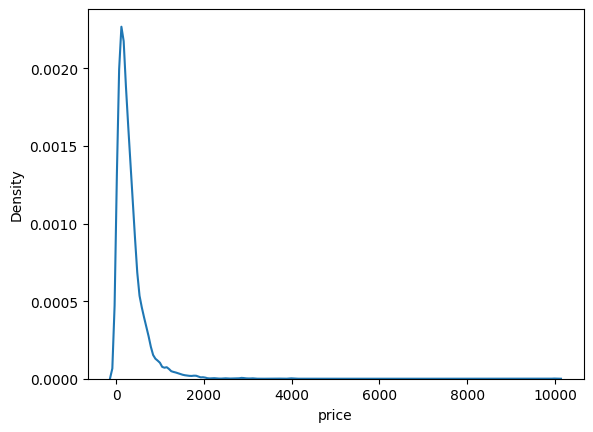

In [13]:
#2 Inspecting features,stats, distribution one by one
a= num_cols[1]
print(a)

feature= X_train[a]
print("Null Values:",feature.isnull().sum())
print(feature.describe())

sns.kdeplot(feature, gridsize=200)
plt.show()

<h4 style="color:#C00000;"> 3.1 [A] min-max scaling</h4>

In [14]:
#3. min-max scaling chosen for now
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train[num_cols]= scaler.fit_transform(X_train[num_cols])           #scaling X_train
X_test[num_cols]= scaler.fit_transform(X_test[num_cols])             #scaling X_test
X_cv[num_cols]= scaler.fit_transform(X_cv[num_cols])             #scaling X_test

print(X_train.shape)
print(X_test.shape)
print(X_cv.shape)

X_cv.head(2)

(27214, 13)
(9833, 13)
(6883, 13)


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
103910,p036927,ms,oh,grades_prek_2,appliedlearning_specialneeds,earlydevelopment_specialneeds,0.00000,0.029815,0.002478,class calming corner,students ever changing group 3 4 5 year olds m...,students_need_calming_corner_within_classroom_...,0.0
88567,p238735,mrs,fl,grades_prek_2,math_science,health_lifescience,0.13948,0.021946,0.002478,hoot hoot hooray first grade scientists,classroom made 20 amazing learners come class ...,students_need_real_specimen_sets_observe_learn...,0.0


<h3 style="color:#C00000;"> 3.2 Handling Categorical features</h3>

In [15]:
#1 Geting list of categorical columns (above function not used)
def get_categorical_columns(df):
    cat_cols = []
    for col in df.columns:
        if df[col].nunique() < 405 and df[col].dtype == 'O':
            cat_cols.append(col)
    return cat_cols



cat_cols = get_categorical_columns(X_train)
print(cat_cols)

['teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories']


In [16]:
def column_info(df):
    """
    This function gives following information about all the column
    column Name: datatypes of column: Carinatity-value
    """
    for col in df.columns:
        print(f"{col} : {df[col].dtype} : Cardinatilty- {df[col].nunique()}")


column_info(X_train)

id : object : Cardinatilty- 16058
teacher_prefix : object : Cardinatilty- 5
school_state : object : Cardinatilty- 51
project_grade_category : object : Cardinatilty- 4
project_subject_categories : object : Cardinatilty- 49
project_subject_subcategories : object : Cardinatilty- 322
teacher_number_of_previously_posted_projects : float64 : Cardinatilty- 246
price : float64 : Cardinatilty- 11342
quantity : float64 : Cardinatilty- 217
cleaned_titles : object : Cardinatilty- 14830
cleaned_essays : object : Cardinatilty- 16032
cleaned_summary : object : Cardinatilty- 16024
isdigit_summary : float64 : Cardinatilty- 2


#### pd.get_dummies()  is not returning same size so using countvectorizer fitting over X_train

In [17]:
#Encoding 'teacher_prefix'
#['teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories']
from sklearn.feature_extraction.text import CountVectorizer
vectorizor_tp=  CountVectorizer()
vectorizor_tp.fit(X_train['teacher_prefix'].values)  #has fit on train data only

#tranforming train, test, cv
X_train_teacher_prefix = vectorizor_tp.transform(X_train['teacher_prefix'].values)
X_test_teacher_prefix = vectorizor_tp.transform(X_test['teacher_prefix'].values)
X_cv_teacher_prefix = vectorizor_tp.transform(X_cv['teacher_prefix'].values)

print('After Transformation(Encoding)- teacher_prefix')
print(X_train_teacher_prefix.shape)
print(X_test_teacher_prefix.shape)
print(X_cv_teacher_prefix.shape)


##################################################
#Encoding 'school_state''
vectorizor_ss=  CountVectorizer()
vectorizor_ss.fit(X_train['school_state'].values)  #has fit on train data only

#tranforming train, test, cv
X_train_school_state = vectorizor_ss.transform(X_train['school_state'].values)
X_test_school_state = vectorizor_ss.transform(X_test['school_state'].values)
X_cv_school_state = vectorizor_ss.transform(X_cv['school_state'].values)

print('After Transformation(Encoding)- school_state')
print(X_train_school_state.shape)
print(X_test_school_state.shape)
print(X_cv_school_state.shape)





##################################################
#Encoding 'project_grade_category'
vectorizor_pgc=  CountVectorizer()
vectorizor_pgc.fit(X_train['project_grade_category'].values)  #has fit on train data only

#tranforming train, test, cv
X_train_pgc = vectorizor_pgc.transform(X_train['project_grade_category'].values)
X_test_pgc = vectorizor_pgc.transform(X_test['project_grade_category'].values)
X_cv_pgc = vectorizor_pgc.transform(X_cv['project_grade_category'].values)

print('After Transformation(Encoding)- project_grade_category-pgc')
print(X_train_pgc.shape)
print(X_test_pgc.shape)
print(X_cv_pgc.shape)





##################################################
#Encoding 'project_subject_categories'- [psc]
vectorizor_psc=  CountVectorizer()
vectorizor_psc.fit(X_train['project_subject_categories'].values)  #has fit on train data only

#tranforming train, test, cv
X_train_psc = vectorizor_psc.transform(X_train['project_subject_categories'].values)
X_test_psc = vectorizor_psc.transform(X_test['project_subject_categories'].values)
X_cv_psc = vectorizor_psc.transform(X_cv['project_subject_categories'].values)

print('After Transformation(Encoding)- project_subject_categories-psc')
print(X_train_psc.shape)
print(X_test_psc.shape)
print(X_cv_psc.shape)




###################################################
#Encoding 'project_subject_subcategories'- [pssc]
vectorizor_pssc=  CountVectorizer()
vectorizor_pssc.fit(X_train['project_subject_subcategories'].values)  #has fit on train data only

#tranforming train, test, cv
X_train_pssc = vectorizor_pssc.transform(X_train['project_subject_subcategories'].values)
X_test_pssc = vectorizor_pssc.transform(X_test['project_subject_subcategories'].values)
X_cv_pssc = vectorizor_pssc.transform(X_cv['project_subject_subcategories'].values)

print('After Transformation(Encoding)- project_subject_subcategories  pssc')
print(X_train_pssc.shape)
print(X_test_pssc.shape)
print(X_cv_pssc.shape)

After Transformation(Encoding)- teacher_prefix
(27214, 5)
(9833, 5)
(6883, 5)
After Transformation(Encoding)- school_state
(27214, 51)
(9833, 51)
(6883, 51)
After Transformation(Encoding)- project_grade_category-pgc
(27214, 4)
(9833, 4)
(6883, 4)
After Transformation(Encoding)- project_subject_categories-psc
(27214, 49)
(9833, 49)
(6883, 49)
After Transformation(Encoding)- project_subject_subcategories  pssc
(27214, 322)
(9833, 322)
(6883, 322)


<h3 style="color:#C00000;"> 3.3 Text Featurization </h3>

In [18]:
#1. Getting text column, [Except: id]
def get_text_features(df):
    txt_cols = []
    for col in df.columns:
        if df[col].nunique() >401 and df[col].dtype == 'O':
            txt_cols.append(col)
    return txt_cols

txt_cols = get_text_features(X_train)
print(txt_cols)
txt_cols.pop(0)
print(txt_cols)

['id', 'cleaned_titles', 'cleaned_essays', 'cleaned_summary']
['cleaned_titles', 'cleaned_essays', 'cleaned_summary']


In [26]:
#2 checking null values one by one and imputing: missing value as info
d= X_cv    #change: X_test, X_train, X_cv :: txt_cols[0]
a= txt_cols[0]
print("Null in ",a,":", d[a].isnull().sum())
print("Cardinality ",a,":", d[a].nunique())
X_test


#imputing: missing value-as info
if d[a].isnull().sum()>0:
    d[a]= d[a].fillna('Unavilable')
    print('Imputed')
else:
    print('no null values')

Null in  cleaned_titles : 3
Cardinality  cleaned_titles : 6534
Imputed


<b> Observed that df['cleaned_summary'] need some preprocessings </b>

In [27]:
X['cleaned_summary'].head(2)

50606    students_need_game_activity_school_program_clu...
56441    students_need_checks_balances_kit_learn_money_...
Name: cleaned_summary, dtype: object

In [28]:
import re
def replace_underscores(text):
    return re.sub(r'_', ' ', text)

X_train['cleaned_summary']= X_train['cleaned_summary'].apply(replace_underscores)
X_test['cleaned_summary']= X_test['cleaned_summary'].apply(replace_underscores)
X_cv['cleaned_summary']= X_cv['cleaned_summary'].apply(replace_underscores)

print(X_train.shape)
X_train.head(2)

(27214, 13)


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p040362,mrs,il,grades_prek_2,literacy_language,literature_writing,0.033097,0.019116,0.004449,wobble learn,teach first grade small farming town illinois ...,students need wobble stools expand alternative...,0.0
1,p094634,ms,ca,grades_9_12,literacy_language,esl_literacy,0.011820,0.017987,0.070078,bilingual picture dictionaries newly arrived i...,school urban public middle school oakland cali...,students need basic bilingual picture dictiona...,0.0


<h3 style="color:#C00000;"> 3.3 [A] Bag of Words (All text features) </h3>

In [29]:
#checking null values before vectorizing
print(txt_cols,":By null values")
for i in txt_cols:
  print("In X_train-",i, X_train[i].isnull().sum())
  print("In X_test-",i, X_test[i].isnull().sum())
  print("In X_cv-", i, X_cv[i].isnull().sum())

['cleaned_titles', 'cleaned_essays', 'cleaned_summary'] :By null values
In X_train- cleaned_titles 0
In X_test- cleaned_titles 0
In X_cv- cleaned_titles 0
In X_train- cleaned_essays 0
In X_test- cleaned_essays 0
In X_cv- cleaned_essays 0
In X_train- cleaned_summary 0
In X_test- cleaned_summary 0
In X_cv- cleaned_summary 0


In [30]:
#1. 'cleaned_titles'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer for 'cleaned_titles'
vectorizer_titles = CountVectorizer(min_df=5, max_features=3000)
vectorizer_titles.fit(X_train['cleaned_titles'])  # Fit only on the training data

# Transform the 'cleaned_titles' column in train, test, and cv sets
X_train_title_bow = vectorizer_titles.transform(X_train['cleaned_titles'].values)
X_test_title_bow = vectorizer_titles.transform(X_test['cleaned_titles'].values)
X_cv_title_bow = vectorizer_titles.transform(X_cv['cleaned_titles'].values)

# Print the shapes of the transformed data
print("After Vectorization:")
print("X_train_title_bow shape:", X_train_title_bow.shape)
print("X_test_title_bow shape:", X_test_title_bow.shape)
print("X_cv_title_bow shape:", X_cv_title_bow.shape)

After Vectorization:
X_train_title_bow shape: (27214, 2501)
X_test_title_bow shape: (9833, 2501)
X_cv_title_bow shape: (6883, 2501)


In [31]:
#2.Bow: Project essay
#'cleaned_essays'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
vectorizer_essay = CountVectorizer(min_df=5, max_features=3000)
vectorizer_essay.fit(X_train['cleaned_essays'])    #fit has happned only on train data

X_train_essays_bow= vectorizer_essay.transform(X_train['cleaned_essays'].values)
X_test_essays_bow= vectorizer_essay.transform(X_test['cleaned_essays'].values)
X_cv_essays_bow= vectorizer_essay.transform(X_cv['cleaned_essays'].values)


print("After Vectorization")
print("X_train_essays_bow shape:", X_train_essays_bow.shape)
print("X_test_essays_bow shape:", X_test_essays_bow.shape)
print("X_cv_essays_bow shape:", X_cv_essays_bow.shape)

After Vectorization
X_train_essays_bow shape: (27214, 3000)
X_test_essays_bow shape: (9833, 3000)
X_cv_essays_bow shape: (6883, 3000)


In [32]:
#3.Bow: 'cleaned_summary'
#'cleaned_summary'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
vectorizer_summary = CountVectorizer(min_df=5, max_features=2500)
vectorizer_summary.fit(X_train['cleaned_summary'])    #fit has happned only on train data


X_train_summary_bow= vectorizer_summary.transform(X_train['cleaned_summary'].values)
X_test_summary_bow= vectorizer_summary.transform(X_test['cleaned_summary'].values)
X_cv_summary_bow= vectorizer_summary.transform(X_cv['cleaned_summary'].values)


print("After Vectorization")
print("X_train_summary_bow shape:", X_train_summary_bow.shape)
print("X_test_summary_bow shape:", X_test_summary_bow.shape)
print("X_cv_summary_bow shape:", X_cv_summary_bow.shape)

After Vectorization
X_train_summary_bow shape: (27214, 2500)
X_test_summary_bow shape: (9833, 2500)
X_cv_summary_bow shape: (6883, 2500)


<h3 style="color:#C00000;"> 3.3 [B] tf-idf Vectorizor (All text features) </h3>

In [33]:
#1.Tf-idf: Project titles
#'cleaned_titles'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the CountVectorizer for
vectorizer_titles = TfidfVectorizer(min_df=5, max_features=2000)
vectorizer_titles.fit(X_train['cleaned_titles'])    #fit has happned only on train data

X_train_title_tfidf= vectorizer_titles.transform(X_train['cleaned_titles'].values)
X_test_title_tfidf= vectorizer_titles.transform(X_test['cleaned_titles'].values)
X_cv_title_tfidf= vectorizer_titles.transform(X_cv['cleaned_titles'].values)


print("After Vectorization")
print("X_train_title_tfidf shape:", X_train_title_tfidf.shape)
print("X_test_title_tfidf shape:", X_test_title_tfidf.shape)
print("X_cv_title_tfidf shape:", X_cv_title_tfidf.shape)

After Vectorization
X_train_title_tfidf shape: (27214, 2000)
X_test_title_tfidf shape: (9833, 2000)
X_cv_title_tfidf shape: (6883, 2000)


In [34]:
#2.Tfidf: Project essay
#'cleaned_essays'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the CountVectorizer
vectorizer_essay = TfidfVectorizer(min_df=10, max_features=3000)
vectorizer_essay.fit(X_train['cleaned_essays'])    #fit has happned only on train data

X_train_essays_tfidf= vectorizer_essay.transform(X_train['cleaned_essays'].values)
X_test_essays_tfidf= vectorizer_essay.transform(X_test['cleaned_essays'].values)
X_cv_essays_tfidf= vectorizer_essay.transform(X_cv['cleaned_essays'].values)


print("After Vectorization")
print("X_train_essays_tfidfshape:", X_train_essays_tfidf.shape)
print("X_test_essays_tfidf shape:", X_test_essays_tfidf.shape)
print("X_cv_essays_tfidf shape:", X_cv_essays_tfidf.shape)

After Vectorization
X_train_essays_tfidfshape: (27214, 3000)
X_test_essays_tfidf shape: (9833, 3000)
X_cv_essays_tfidf shape: (6883, 3000)


In [35]:
X_test   #just a check

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
70168,p169721,ms,wa,grades_prek_2,music_arts,visualarts,0.009153,0.019645,0.005008,painting preschoolers,3 5 year olds know play hard work hard sort le...,students need new painting aprons need space s...,0.0
41265,p037252,ms,tx,grades_3_5,health_sports,health_wellness,0.041190,0.016352,0.033389,targeting physical fitness,year special one school brand new new wonderfu...,students need assortment physical fitness equi...,0.0
43571,p064455,mrs,mi,grades_prek_2,appliedlearning,earlydevelopment,0.000000,0.020254,0.038397,using tools build firm foundation,classroom made 18 pre schoolers aged 4 5 end s...,students need real pretend tools explore world...,1.0
54294,p255403,mrs,wv,grades_3_5,literacy_language,literacy,0.151030,0.016165,0.005008,getting comfy good book,currently twenty one wonderful third grade stu...,students need bean bag chairs use classroom re...,0.0
8128,p123532,ms,nc,grades_9_12,literacy_language,esl_literacy,0.004577,0.014199,0.121870,read write create,believe necessary utilize various learning sty...,students need basic school supplies well art s...,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46817,p062972,ms,wi,grades_prek_2,health_sports,health_wellness,0.002288,0.010642,0.010017,healthy start learning,students attend public school houses kindergar...,students need seven hokki stools help get wigg...,0.0
99742,p249801,mrs,fl,grades_prek_2,math_science,appliedsciences_mathematics,0.004577,0.037646,0.000000,little scientists,school starts back august teaching 18 kinderga...,students need variety fun resources fully deve...,0.0
106122,p143681,mrs,nm,grades_prek_2,appliedlearning,communityservice_earlydevelopment,0.059497,0.017336,0.001669,long lasting materials equals long lasting lea...,remove repost items classroom wear materials l...,students need assistance protecting classroom ...,0.0
81912,p012439,ms,or,grades_prek_2,literacy_language_music_arts,literacy_performingarts,0.002288,0.015990,0.003339,learning world puppets,work group fun energitic kindergarteners new f...,students need play materials support literacy ...,0.0


In [36]:
#3.tf-idf: 'cleaned_summary'
#'cleaned_summary'/ ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the CountVectorizer
vectorizer_summary = TfidfVectorizer(min_df=10, max_features=2500)
vectorizer_summary.fit(X_train['cleaned_summary'])    #fit has happned only on train data


X_train_summary_tfidf= vectorizer_summary.transform(X_train['cleaned_summary'].values)
X_test_summary_tfidf= vectorizer_summary.transform(X_test['cleaned_summary'].values)
X_cv_summary_tfidf= vectorizer_summary.transform(X_cv['cleaned_summary'].values)


print("After Vectorization")
print("X_train_summary_tfidf shape:", X_train_summary_tfidf.shape)
print("X_test_summary_tfidf shape:", X_test_summary_tfidf.shape)
print("X_cv_summary_tfidf shape:", X_cv_summary_tfidf.shape)

After Vectorization
X_train_summary_tfidf shape: (27214, 2500)
X_test_summary_tfidf shape: (9833, 2500)
X_cv_summary_tfidf shape: (6883, 2500)


# Avg W2Veck and tfidfweighted W2v

## Promopt

In my donor choose dataset, I have 3 preprocessed text features ['cleaned_titles', 'cleaned_essays', 'cleaned_summary'].  now I need to featurize these. I have splitter dataset in X_train, X_test, X_cv before feturizing in order to avoid lekage now i need to do:
1. Word2Vec (This is defined for vocab in corpus)
2. AvgWord2Vec (defined for each document (data points )
3. tfidf Word2Vec (defined for each document (data points )

suggest me industry standard best practice, give me separate code for all three

<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        4. Modeling: Machine Learning Model
    </h1>
</div>

## Assignment 4
<b>Apply Multinomial NaiveBayes on these feature sets</b>

1. : categorical, numerical features + project_title(BOW) + preprocessed_eassay (BOW)
2. : categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)

<b>The hyper paramter tuning(find best Alpha)</b>

- Find the best hyper parameter which will give the maximum AUC value
- Consider a wide range of alpha values for hyperparameter tuning, start as low as 0.00001
- Find the best hyper paramter using k-fold cross validation or simple cross validation data
- Use gridsearch cv or randomsearch cv or you can also write your own for loops to do this task of hyperparameter tuning

<b>Feature importance</b>

- : Find the top 10 features of positive class and top 10 features of negative class for both feature sets and using values of feature_log_prob_ parameter of MultinomialNB and print their corresponding feature names

<b>Representation of results</b>

- : You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure. Here on X-axis you will have alpha values, since they have a wide range, just to represent those alpha values on the graph, apply log function on those alpha values.

- : Once after you found the best hyper parameter, you need to train your model with it, and find the AUC on test data and plot the ROC curve on both train and test.

- : Along with plotting ROC curve, you need to print the confusion matrix with predicted and original labels of test data points. Please visualize your confusion matrices using seaborn heatmaps.

<b>Conclusion</b>

- : You need to summarize the results at the end of the notebook, summarize it in the table format. To print out a table please refer to this prettytable library link

<h3 style="color:#C00000;"> Preparing [Set 1] for Task 1 </h3>

In [37]:
# Set 1: categorical, numerical features + project_title(BOW) + preprocessed_essay (BOW)
#In this cell : Make Numarical and categorical into same csr format


#numarical_features
from scipy.sparse import hstack, csr_matrix
X_train_numcol = csr_matrix(X_train[['teacher_number_of_previously_posted_projects', 'price', 'quantity', 'isdigit_summary']])
X_test_numcol  = csr_matrix(X_test[['teacher_number_of_previously_posted_projects', 'price', 'quantity', 'isdigit_summary']])
X_cv_numcol    = csr_matrix(X_cv[['teacher_number_of_previously_posted_projects', 'price', 'quantity', 'isdigit_summary']])

print('numarical_features')
print(X_train_numcol.shape)
print(X_test_numcol.shape)
print(X_cv_numcol.shape)




#################################################
#combining all categrorical features encoded
from scipy.sparse import hstack

# Combine all the vectorized features
X_train_cat_combined = hstack([X_train_teacher_prefix, X_train_school_state, X_train_pgc, X_train_psc, X_train_pssc])
X_test_cat_combined = hstack([X_test_teacher_prefix, X_test_school_state, X_test_pgc, X_test_psc, X_test_pssc])
X_cv_cat_combined = hstack([X_cv_teacher_prefix, X_cv_school_state, X_cv_pgc, X_cv_psc, X_cv_pssc])

print('categrorical features')
print(X_train_cat_combined.shape)
print(X_test_cat_combined.shape)
print(X_cv_cat_combined.shape)

numarical_features
(27214, 4)
(9833, 4)
(6883, 4)
categrorical features
(27214, 431)
(9833, 431)
(6883, 431)


In [38]:
# Set 1: categorical, numerical features + project_title(BOW) + preprocessed_essay (BOW)

# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack


## Set 1: categorical, numerical features + project_title(BOW) + preprocessed_essay (BOW)
X_train1= hstack((X_train_numcol, X_train_cat_combined, X_train_title_bow, X_train_essays_bow)).tocsr()        #train
X_cv1= hstack((X_cv_numcol, X_cv_cat_combined,X_cv_title_bow, X_cv_essays_bow)).tocsr()                        #cv
X_test1= hstack((X_test_numcol, X_test_cat_combined,X_test_title_bow, X_test_essays_bow)).tocsr()              #test



print(X_train1.shape, y_train.shape)
print(X_cv1.shape, y_cv.shape)
print(X_test1.shape, y_test.shape)

(27214, 5936) (27214,)
(6883, 5936) (6883,)
(9833, 5936) (9833,)


<b> set2: categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)

In [39]:
# Set 2: categorical, numerical features + project_title(tfidf) + preprocessed_essay (tfidf)

# merge two sparse matrices: https://stackoverflow.com/a/19710648/4084039
from scipy.sparse import hstack


## Set 1: categorical, numerical features + project_title(BOW) + preprocessed_essay (BOW)
X_train2= hstack((X_train_numcol, X_train_cat_combined, X_train_title_tfidf, X_train_essays_tfidf)).tocsr()        #train
X_cv2= hstack((X_cv_numcol, X_cv_cat_combined,X_cv_title_tfidf, X_cv_essays_tfidf)).tocsr()                        #cv
X_test2= hstack((X_test_numcol, X_test_cat_combined,X_test_title_tfidf, X_test_essays_tfidf)).tocsr()              #test


print(X_train2.shape, y_train.shape)
print(X_cv2.shape, y_cv.shape)
print(X_test2.shape, y_test.shape)

(27214, 5435) (27214,)
(6883, 5435) (6883,)
(9833, 5435) (9833,)


<h3 style="color:#C00000;"> <b>4.2 Modeling on Set 1</b></h3>

Multinomial NaiveBayes on- <b>Set 1:</b> categorical, numerical features + project_title(BOW) + preprocessed_essay (BOW)

In [40]:
#Exercise-Default hyperparameter
from sklearn.naive_bayes import MultinomialNB

clf1 = MultinomialNB()
clf1.fit(X_train1, y_train)


# roc_auc_score(y_true, y_score): 2nd parameter should be probability estimates of the positive class
y_pred_train1 = clf1.predict_proba(X_train1)[:,1]
y_pred_cv1 = clf1.predict_proba(X_cv1)[:,1]
y_pred_test1 = clf1.predict_proba(X_test1)[:,1]


#evaluating models
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

print('Train AUC:', roc_auc_score(y_train, y_pred_train1))
print('CV AUC:', roc_auc_score(y_cv, y_pred_cv1))
print('Test AUC:', roc_auc_score(y_test, y_pred_test1))

Train AUC: 0.8221280846043209
CV AUC: 0.6945949421413536
Test AUC: 0.6808018373396287


<b> 4.2 [A] Random hyperparameter (alpha in NB) values </b>

In [41]:
#Define Batch wise prediction function: A neat implementational practice

def batch_predict(clf, data):
    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs

    y_data_pred = []
    tr_loop = data.shape[0] - data.shape[0]%1000
    # consider you X_tr shape is 49041, then your cr_loop will be 49041 - 49041%1000 = 49000

    # in this for loop we will iterate unti the last 1000 multiplier
    for i in range(0, tr_loop, 1000):
        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])
    # we will be predicting for the last data points
    y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])

    return y_data_pred

100%|██████████| 9/9 [00:00<00:00, 89877.94it/s]


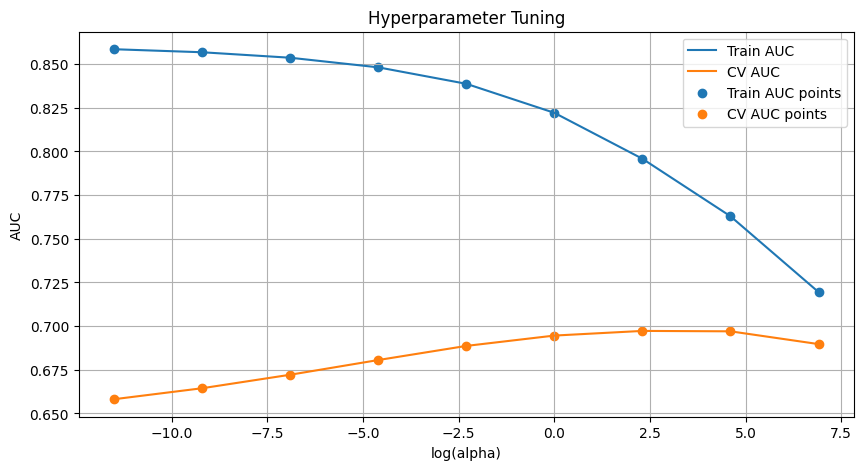

In [42]:
#In action code--
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
import math

train_auc = []
cv_auc = []
log_alphas = []

alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10,  100,  1000]

for i in tqdm(alphas):
    nb = MultinomialNB(alpha = i,class_prior=[0.5,0.5])
    nb.fit(X_train1, y_train)

    y_train_pred = batch_predict(nb, X_train1)
    y_cv_pred = batch_predict(nb, X_cv1)

    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs
    train_auc.append(roc_auc_score(y_train,y_train_pred))
    cv_auc.append(roc_auc_score(y_cv, y_cv_pred))

for a in tqdm(alphas):
    b = math.log(a)
    log_alphas.append(b)


#ploting
plt.figure(figsize=(10,5))
plt.plot(log_alphas, train_auc, label='Train AUC')
plt.plot(log_alphas, cv_auc, label='CV AUC')

plt.scatter(log_alphas, train_auc, label='Train AUC points')
plt.scatter(log_alphas, cv_auc, label='CV AUC points')
plt.legend()
plt.xlabel("log(alpha)")
plt.ylabel("AUC")
plt.title("Hyperparameter Tuning")
plt.grid()
plt.show()

<b> 4.2 [B] Gridsearch-cv using  [K(cv=10) fold cross validation]

100%|██████████| 11/11 [00:00<00:00, 5315.36it/s]


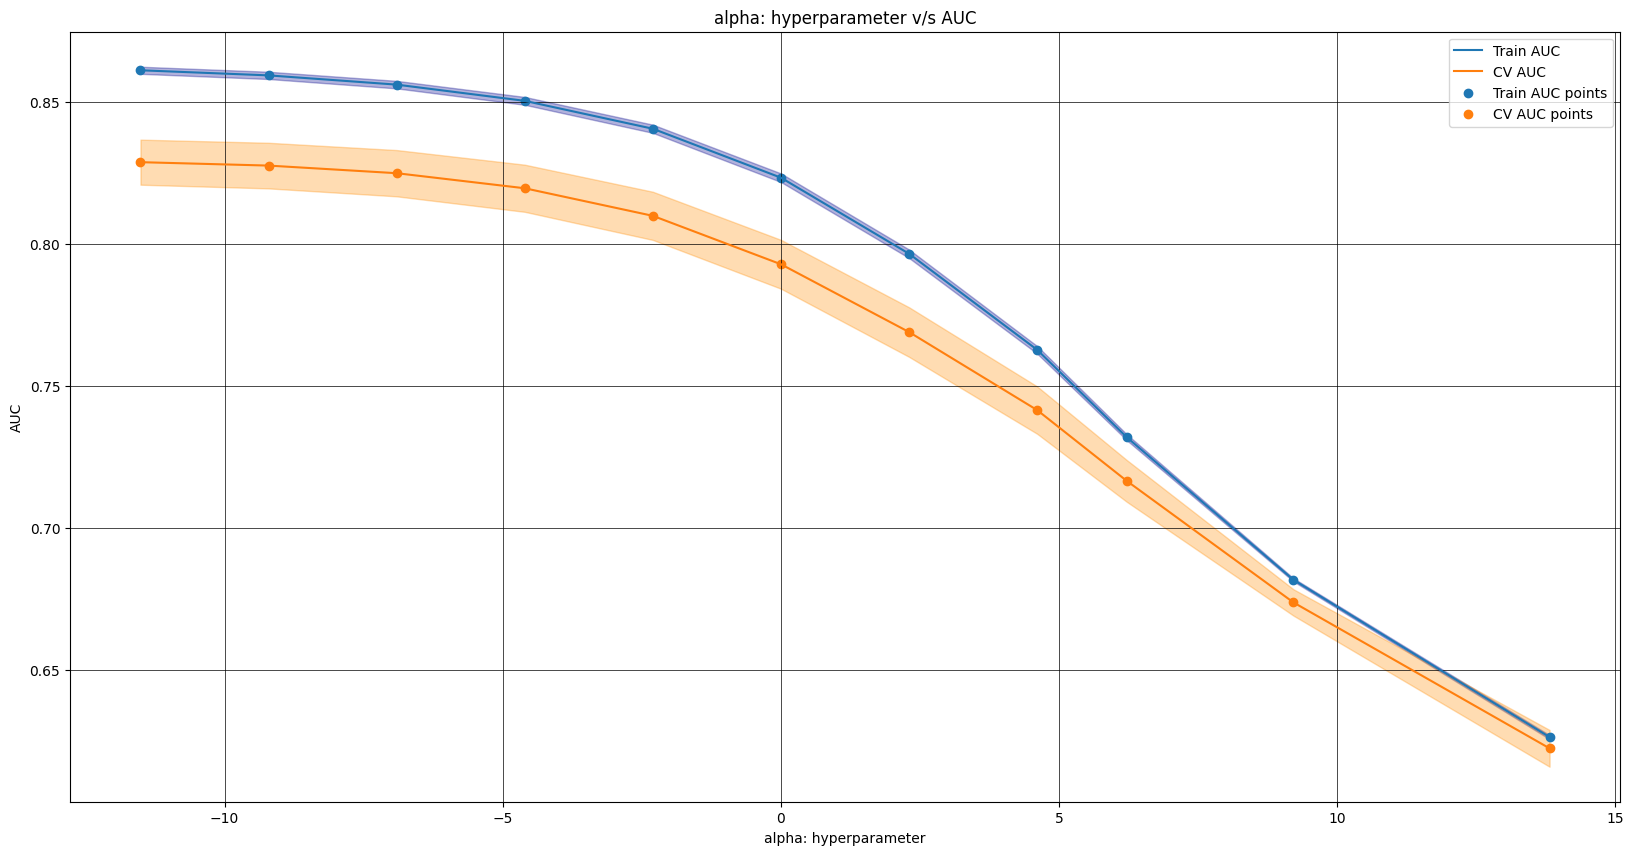

Best alpha found: 1e-05


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score


parameters= {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1,1,10,100,500,10000,1000000]}
nb = MultinomialNB(class_prior=[0.5,0.5])

clf = GridSearchCV(nb, parameters, cv=10, scoring='roc_auc', return_train_score=True)
clf.fit(X_train1, y_train)

# Retrieve results from GridSearchCV (returns dictnaries)
results = clf.cv_results_

# Extract mean and std for training and cross-validation AUC
train_auc = results['mean_train_score']                         #'mean_train_score':  avg(train auc) for each HP across k folds
train_auc_std = results['std_train_score']                      #'std_train_score':  std dev for each HP across k folds
cv_auc = results['mean_test_score']
cv_auc_std = results['std_test_score']

#Now scaling alpha with log
log_alphas =[]

for a in tqdm(parameters['alpha']):
    b = math.log(a)
    log_alphas.append(b)

#plotting the train and cv auc (with std), in same figure
plt.figure(figsize=(20,10))

# train_auc (+-) train_auc_stdev, shading
plt.plot(log_alphas, train_auc, label='Train AUC')
plt.gca().fill_between(log_alphas,train_auc - train_auc_std,train_auc + train_auc_std,alpha=0.3,color='darkblue')

#cv_auc (+-) cv_auc_stdv (for each HP across k folds), fill the region
plt.plot(log_alphas, cv_auc, label='CV AUC')
plt.gca().fill_between(log_alphas,cv_auc - cv_auc_std,cv_auc + cv_auc_std,alpha=0.3,color='darkorange')

plt.scatter(log_alphas, train_auc, label='Train AUC points')
plt.scatter(log_alphas, cv_auc, label='CV AUC points')

plt.legend()
plt.xlabel("alpha: hyperparameter")
plt.ylabel("AUC")
plt.title("alpha: hyperparameter v/s AUC")
plt.grid(color='black', linestyle='-', linewidth=0.5)
plt.show()



#get best alpha
best_alpha = clf.best_params_['alpha']
print("Best alpha found:", best_alpha)

<b>[C] Training model using the best hyper-parameter value

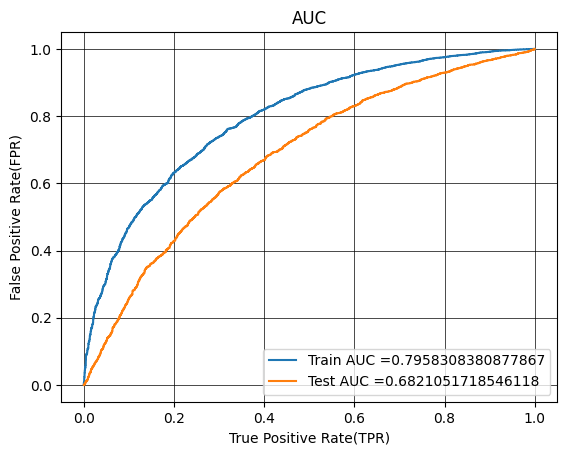

In [55]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve
from sklearn.metrics import roc_curve, auc

nb_bow = MultinomialNB(alpha = 10, class_prior=[0.5,0.5])

nb_bow.fit(X_train1, y_train)
# roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
# not the predicted outputs

y_train_pred = batch_predict(nb_bow, X_train1)
y_test_pred = batch_predict(nb_bow, X_test1)

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred)

plt.plot(train_fpr, train_tpr, label="Train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="Test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("True Positive Rate(TPR)")
plt.ylabel("False Positive Rate(FPR)")
plt.title("AUC")
plt.grid(color='black', linestyle='-', linewidth=0.5)
plt.show()

<h3 style="color:red;"></h3>